## Phase 3 — Machine Learning Modelling

### Overview
Two parallel tasks:
- Task A → XGBoost churn prediction model
- Task B → K-Means customer segmentation

Input file : feature_matrix.csv        (Task A)
Input file : feature_matrix_scaled.csv (Task B)
Target     : churned (0 = active, 1 = churned)
Dataset    : 16,737 customers × 24 features

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score,
                              roc_curve)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
df = pd.read_csv('modelling2.csv')

# Verify
print(f"Shape: {df.shape}")
print(f"\nChurn distribution:")
print(df['churned'].value_counts())
print(f"\nChurn rate: {df['churned'].mean()*100:.1f}%")

Shape: (16737, 33)

Churn distribution:
churned
0    14051
1     2686
Name: count, dtype: int64

Churn rate: 16.0%


In [2]:
df = df.drop('Unnamed: 0', axis=1)

# Chrun prediction
- RF
- XGB
- Logistic Reg

In [3]:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler

df_scaled  = StandardScaler().fit_transform(df.drop('churned', axis=1))
X_train, X_test, y_train, y_test = train_test_split(df_scaled, df['churned'], test_size=0.2, random_state=42, stratify=df['churned'])

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import *

In [5]:
from sklearn.model_selection import GridSearchCV

In [6]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gcv = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)    

In [1]:
gcv.fit(X_train, y_train)

NameError: name 'gcv' is not defined

In [9]:
gcv.best_params_

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}

In [10]:
xgb1 = gcv.best_estimator_

In [11]:
xgb1.predict(X_test)
accuracy_score(y_test, xgb1.predict(X_test))

0.9775985663082437

In [12]:
recall_score(y_test, gcv.best_estimator_.predict(X_test))

0.9124767225325885

In [13]:
# RF
rf = RandomForestClassifier(random_state=42)
param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7]}
gcv3 = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='recall', n_jobs=-1)
gcv3.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [14]:
!pip install imbalanced-learn

In [15]:
%pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [16]:
# SEGMENTATION

In [ ]:
# - kmean - 
# - Agglo
# DBSCAN

In [137]:
df_cl = df.drop('churned', axis=1)

In [138]:
# df_cl

In [139]:

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

In [140]:
#sclaing
X_train = StandardScaler().fit_transform(df_cl)
#clustering

sil = []
wcss = []
for i in range(1,7):
    Km = KMeans(n_clusters=i+1, random_state=42)
    Km.fit(X_train)
    wcss.append(Km.inertia_)
    sil.append(silhouette_score(X_train, Km.labels_))

Text(0.5, 1.0, 'Silhouette Score')

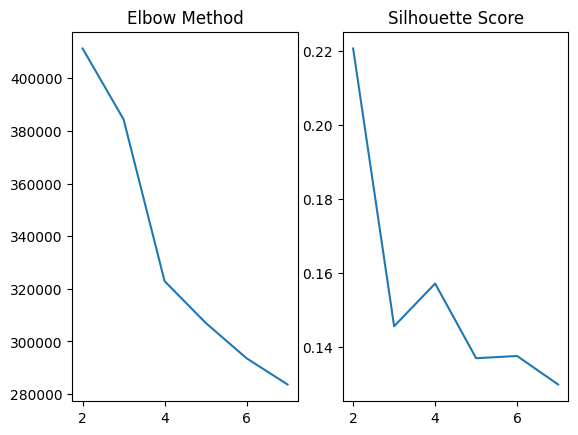

In [141]:
plt.subplot(1, 2, 1)
sns.lineplot(x=range(2, 8), y=wcss)
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
sns.lineplot(x=range(2, 8), y=sil)
plt.title('Silhouette Score')

In [142]:
# Cluster no = 3
km = KMeans(n_clusters=3, random_state=42)
km.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 31)","

In [143]:
km.labels_

array([2, 1, 0, ..., 1, 1, 0], shape=(16737,), dtype=int32)

In [144]:
df_cl['clusters'] = km.labels_

In [ ]:
df_cl


,Salary,CLV,Tenure_Months,Total_Flights,Avg_Flights_Month,Max_Flights_Month,Total_Distance,Avg_Distance_Month,Total_Points_Acc,Total_Points_Red,...,Onehot__Marital Status_Single,Onehot__Enrollment Type_2018 Promotion,Onehot__Enrollment Type_Standard,Onehot__Region_East,Onehot__Region_North,Onehot__Region_West,loyalty_card_encoded,Education_encoded,Flight_consistency_score,clusters
0,83236.0,3839.14,34,37,1.541667,5,54525,2271.875000,54525.0,1418,...,0.0,0.0,1.0,1.0,0.0,0.0,0,2,3.363636,2
1,0.0,3839.61,33,58,2.416667,5,77487,3228.625000,77487.0,1971,...,0.0,0.0,1.0,0.0,0.0,1.0,0,1,8.285714,1
2,0.0,3839.75,53,18,0.750000,4,24803,1033.458333,24803.0,374,...,1.0,0.0,1.0,0.0,0.0,1.0,0,1,1.058824,0
3,0.0,3839.75,70,35,1.458333,5,48432,2018.000000,48432.0,1291,...,1.0,0.0,1.0,1.0,0.0,0.0,0,1,3.500000,2
4,103495.0,3842.79,50,37,1.541667,5,55515,2313.125000,55515.0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0,2,3.083333,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,0.0,61850.19,72,38,1.583333,6,53293,2220.541667,53293.0,0,...,0.0,0.0,1.0,0.0,0.0,1.0,0,1,3.166667,1
16733,89210.0,67907.27,51,59,2.458333,5,86072,3586.333333,86072.0,1645,...,0.0,0.0,1.0,0.0,0.0,1.0,0,2,7.375000,1
16734,0.0,74228.52,57,50,2.083333,6,61595,2566.458333,61595.0,1529,...,1.0,0.0,1.0,0.0,0.0,1.0,0,1,8.333333,1
16735,72026.0,10018.66,8,51,4.636364,20,68843,6258.454545,103264.5,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0,2,10.200000,1


In [146]:
df_cl.to_csv('Clustering.csv')

In [ ]:
xgb1


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None
